# House Price Prediction

Predicting house sale prices from property characteristics using regression models.

**Dataset:** `data/modified_data.csv` — house sales with features such as square footage, bedrooms/bathrooms, condition, location, and year built.

**Goal:** Train a regression model to predict `price` from the other features, and evaluate it on a held-out test set.

## Contents
1. [Load & Inspect Data](#1.-Load-&-Inspect-Data)
2. [Exploratory Data Analysis](#2.-Exploratory-Data-Analysis)
3. [Data Cleaning](#3.-Data-Cleaning)
4. [Data Leakage Check](#4.-Data-Leakage-Check)
5. [Feature Engineering](#5.-Feature-Engineering)
6. [Train / Test Split](#6.-Train-/-Test-Split)
7. [Model Comparison](#7.-Model-Comparison)
8. [Final Model Evaluation](#8.-Final-Model-Evaluation)
9. [Feature Importance](#9.-Feature-Importance)
10. [Conclusion](#10.-Conclusion)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv("data/modified_data.csv")
print(df.shape)
df.head()


(4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   str    
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   str    
 15  city            4600 non-null   str    
 16  statezip        4600 non-null   str    
 17  price_per_sqft  4600 non-null   float64
dtyp

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988470,563834.702545,0.0,322875.0000,460943.460,654962.50,26590000.0
bedrooms,4600.0,3.400870,0.908848,0.0,3.0000,3.000,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.7500,2.250,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.0000,1980.000,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.7500,7683.000,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.0000,1.500,2.00,3.5
waterfront,4600.0,0.007174,0.084404,0.0,0.0000,0.000,0.00,1.0
view,4600.0,0.240652,0.778405,0.0,0.0000,0.000,0.00,4.0
condition,4600.0,3.451739,0.677230,1.0,3.0000,3.000,4.00,5.0
sqft_above,4600.0,1827.265435,862.168977,370.0,1190.0000,1590.000,2300.00,9410.0


In [5]:
# Missing values
df.isna().sum()


date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
dtype: int64

## 2. Exploratory Data Analysis

### 2.1 Price distribution
House prices are heavily right-skewed: most houses cluster at the lower end, with a long tail of very expensive properties. This matters for modeling — a few extreme values can dominate the error metrics, so we'll look at a log-transformed view as well.

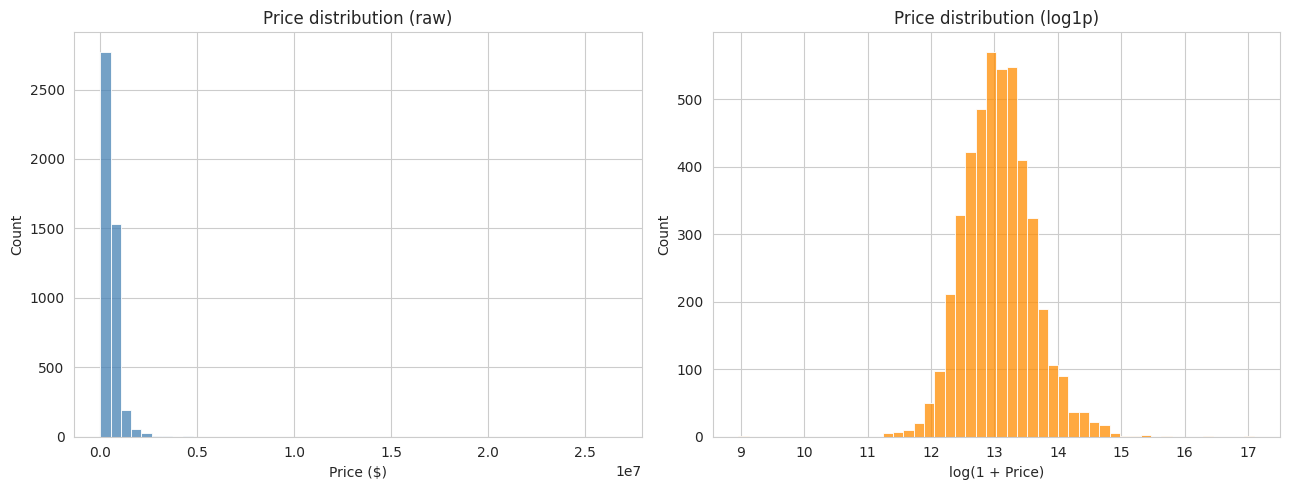

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["price"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price ($)")

sns.histplot(np.log1p(df.loc[df["price"] > 0, "price"]), bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Price distribution (log1p)")
axes[1].set_xlabel("log(1 + Price)")

plt.tight_layout()
plt.show()


### 2.2 Price vs. living area

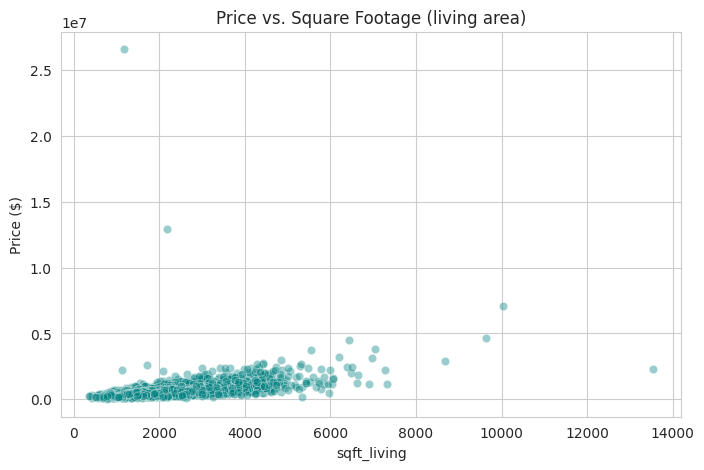

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df[df["price"] > 0], x="sqft_living", y="price", alpha=0.4, color="teal")
plt.title("Price vs. Square Footage (living area)")
plt.xlabel("sqft_living")
plt.ylabel("Price ($)")
plt.show()


### 2.3 Correlation heatmap (numeric features)

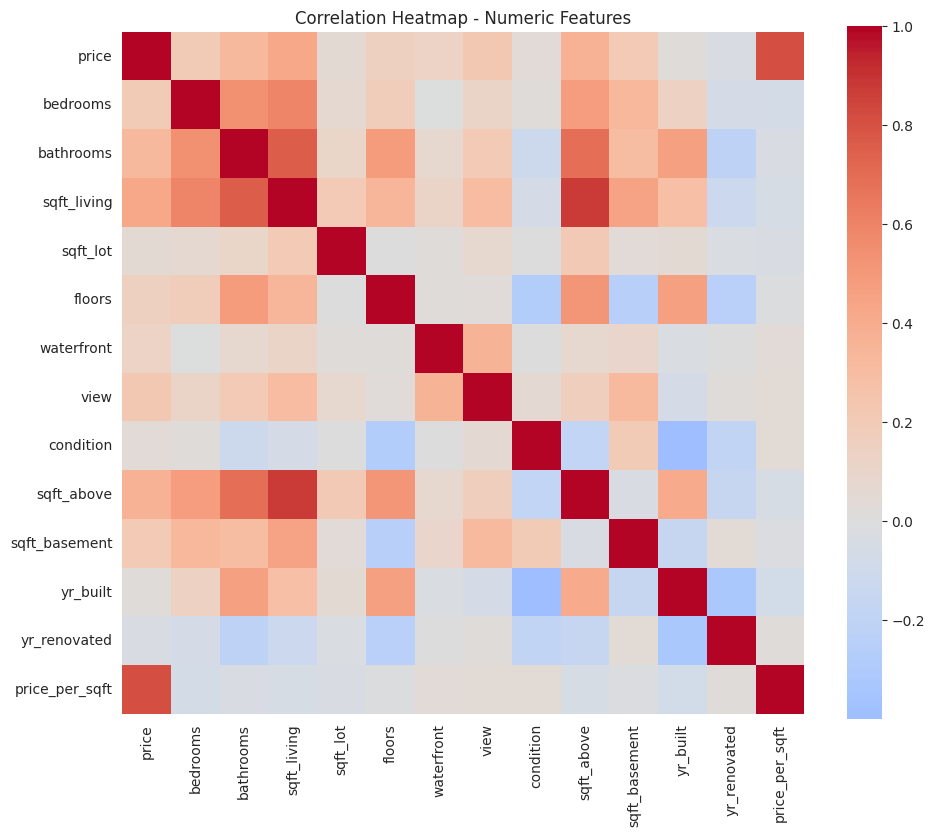

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation Heatmap - Numeric Features")
plt.show()


### 2.4 Average price by city (top 15 by count)

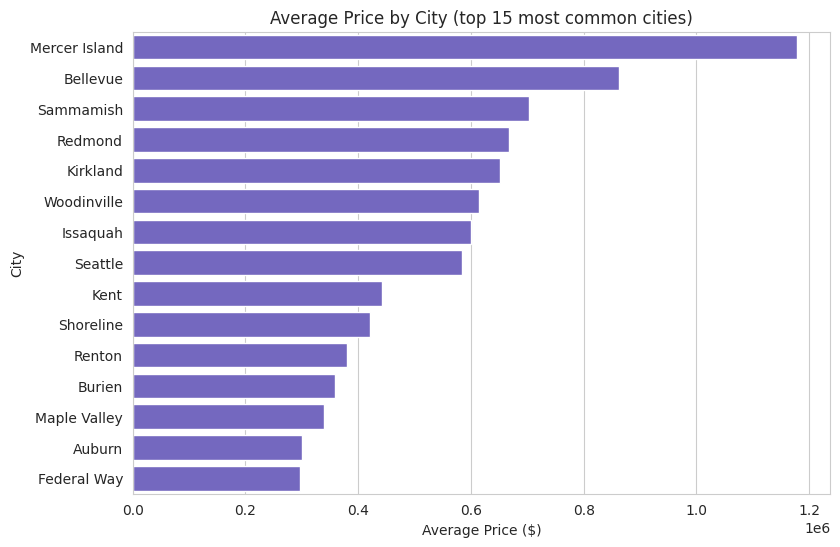

In [9]:
top_cities = df["city"].value_counts().head(15).index
city_avg = (
    df[df["city"].isin(top_cities) & (df["price"] > 0)]
    .groupby("city")["price"].mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))
sns.barplot(x=city_avg.values, y=city_avg.index, color="slateblue")
plt.title("Average Price by City (top 15 most common cities)")
plt.xlabel("Average Price ($)")
plt.ylabel("City")
plt.show()


## 3. Data Cleaning

A number of rows have `price == 0`, which is not a valid sale price — these are almost certainly missing/invalid entries, so they are removed.

In [10]:
print("Rows with price == 0:", (df["price"] == 0).sum())
df = df[df["price"] > 0].copy()
print("Remaining rows:", df.shape[0])


Rows with price == 0: 49
Remaining rows: 4551


## 4. Data Leakage Check

The dataset includes a `price_per_sqft` column. Since `price_per_sqft × sqft_living ≈ price`, this column is **derived from the target** and leaks the answer directly to the model. Including it produces an unrealistically high score that would not generalize to new houses (where you wouldn't know `price_per_sqft` in advance, since it depends on the price itself).

We quantify this below, then drop the column before modeling.

In [11]:
implied_price = df["price_per_sqft"] * df["sqft_living"]
corr_leak = np.corrcoef(df["price"], implied_price)[0, 1]
print(f"Correlation between price and (price_per_sqft * sqft_living): {corr_leak:.6f}")
print()
print("Difference between actual price and implied price (should be ~0 if leaked):")
print((df["price"] - implied_price).abs().describe())


Correlation between price and (price_per_sqft * sqft_living): 1.000000

Difference between actual price and implied price (should be ~0 if leaked):
count    4551.000000
mean        5.258137
std         4.111633
min         0.000000
25%         2.000000
50%         4.500000
75%         7.500000
max        37.600000
dtype: float64


**Conclusion:** the correlation is effectively 1.0 — `price_per_sqft` is reverse-engineered from `price`. It is dropped from the feature set.

## 5. Feature Engineering

- `house_age` — years between the sale date and construction year
- `renovated` — binary flag for whether the house was ever renovated
- `city` — one-hot encoded (handled inside the modeling pipeline)
- Dropped: `price_per_sqft` (leakage), `date` (used only to derive `house_age`), `street` / `statezip` (near-unique identifiers, not useful as raw categorical features)

In [12]:
df["date"] = pd.to_datetime(df["date"])
df["house_age"] = df["date"].dt.year - df["yr_built"]
df["renovated"] = (df["yr_renovated"] > 0).astype(int)

feature_cols_to_drop = ["price", "price_per_sqft", "date", "street", "statezip"]

X = df.drop(columns=feature_cols_to_drop)
y = df["price"]

print("Features used:", list(X.columns))


Features used: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'house_age', 'renovated']


## 6. Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


Train: 3640 rows | Test: 911 rows


## 7. Model Comparison

We build a `scikit-learn` **Pipeline** that one-hot encodes `city` and trains the regressor, so preprocessing never leaks information from the test set. We compare:

- Linear Regression
- Random Forest (raw price target)
- Random Forest (log1p price target, via `TransformedTargetRegressor`)

Each is scored with 5-fold cross-validation on the training set (R²), then evaluated once on the held-out test set.

In [14]:
def build_pipeline(regressor, log_target=False):
    preprocessor = ColumnTransformer(
        transformers=[("city", OneHotEncoder(handle_unknown="ignore"), ["city"])],
        remainder="passthrough",
    )
    if log_target:
        regressor = TransformedTargetRegressor(
            regressor=regressor, func=np.log1p, inverse_func=np.expm1
        )
    return Pipeline(steps=[("preprocess", preprocessor), ("model", regressor)])


models = {
    "Linear Regression": build_pipeline(LinearRegression()),
    "Random Forest (raw price)": build_pipeline(
        RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    ),
    "Random Forest (log price)": build_pipeline(
        RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        log_target=True,
    ),
}

results = []
for name, pipe in models.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "CV R2 (mean)": cv_scores.mean(),
        "Test R2": r2_score(y_test, y_pred),
        "Test MAE": mean_absolute_error(y_test, y_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "Test MAPE %": mean_absolute_percentage_error(y_test, y_pred) * 100,
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df


,CV R2 (mean),Test R2,Test MAE,Test RMSE,Test MAPE %
Model,,,,,
Linear Regression,0.461,0.600,153950.685,243988.755,32.337
Random Forest (raw price),0.198,0.441,128366.018,288501.360,26.559
Random Forest (log price),0.500,0.623,117778.846,236712.197,21.415


## 8. Final Model Evaluation

The table above shows **Random Forest (log price)** has the best test R², lowest MAE, and lowest MAPE of the three, so it's used as the final model below.

In [15]:
best_model_name = results_df["Test R2"].idxmax()
print("Best model:", best_model_name)

final_pipe = models[best_model_name]
y_pred_final = final_pipe.predict(X_test)

print(f"R2 score : {r2_score(y_test, y_pred_final):.3f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred_final):,.0f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_final)):,.0f}")
print(f"MAPE     : {mean_absolute_percentage_error(y_test, y_pred_final) * 100:.2f}%")


Best model: Random Forest (log price)
R2 score : 0.623
MAE      : 117,779
RMSE     : 236,712
MAPE     : 21.42%


### 8.1 Actual vs. Predicted

In [16]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_final.round(0),
})
comparison["Error"] = comparison["Predicted"] - comparison["Actual"]
comparison["Error %"] = (comparison["Error"].abs() / comparison["Actual"] * 100).round(1)
comparison.head(10)


,Actual,Predicted,Error,Error %
0,1225000.0,1092362.0,-132638.0,10.8
1,496752.0,541151.0,44399.0,8.9
2,612500.0,585666.0,-26834.0,4.4
3,265000.0,240866.0,-24134.0,9.1
4,615000.0,617384.0,2384.0,0.4
5,432000.0,399420.0,-32580.0,7.5
6,305000.0,333445.0,28445.0,9.3
7,405000.0,317317.0,-87683.0,21.7
8,349000.0,448060.0,99060.0,28.4
9,839000.0,727471.0,-111529.0,13.3


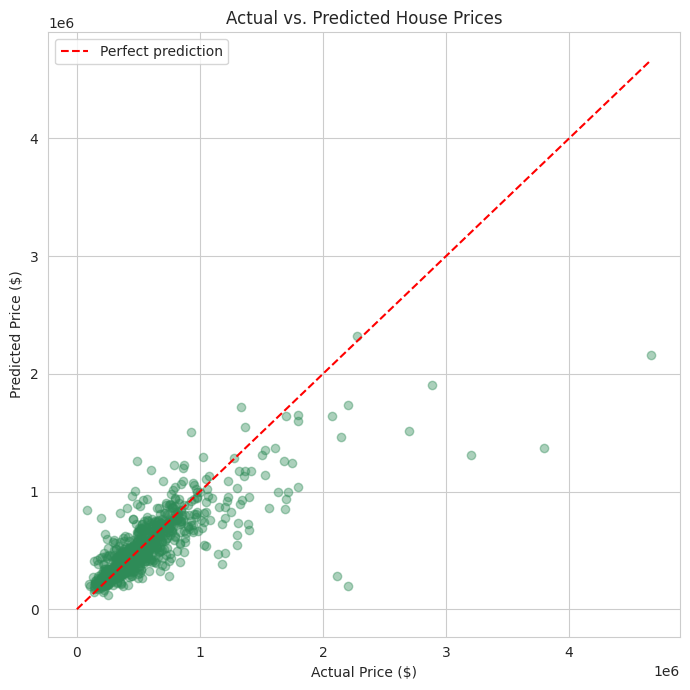

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_final, alpha=0.4, color="seagreen")
lims = [0, max(y_test.max(), y_pred_final.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs. Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()


### 8.2 Residuals

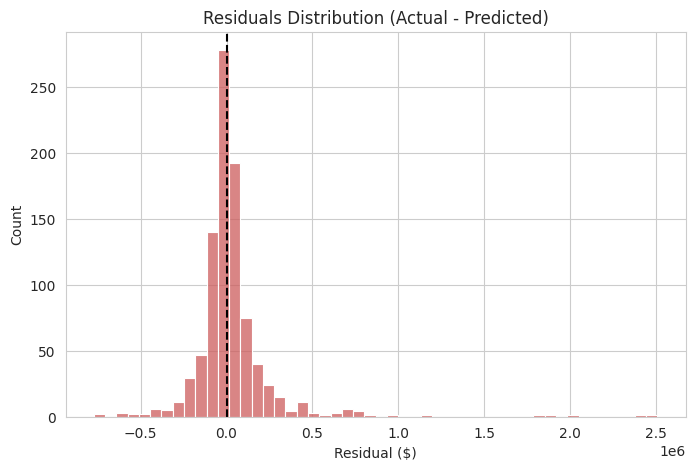

In [18]:
residuals = y_test.values - y_pred_final

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, color="indianred")
plt.axvline(0, color="black", linestyle="--")
plt.title("Residuals Distribution (Actual - Predicted)")
plt.xlabel("Residual ($)")
plt.show()


## 9. Feature Importance

Using the Random Forest model to see which features drive predictions the most (tree-based importances are more informative here than linear coefficients, which are sensitive to feature scale).

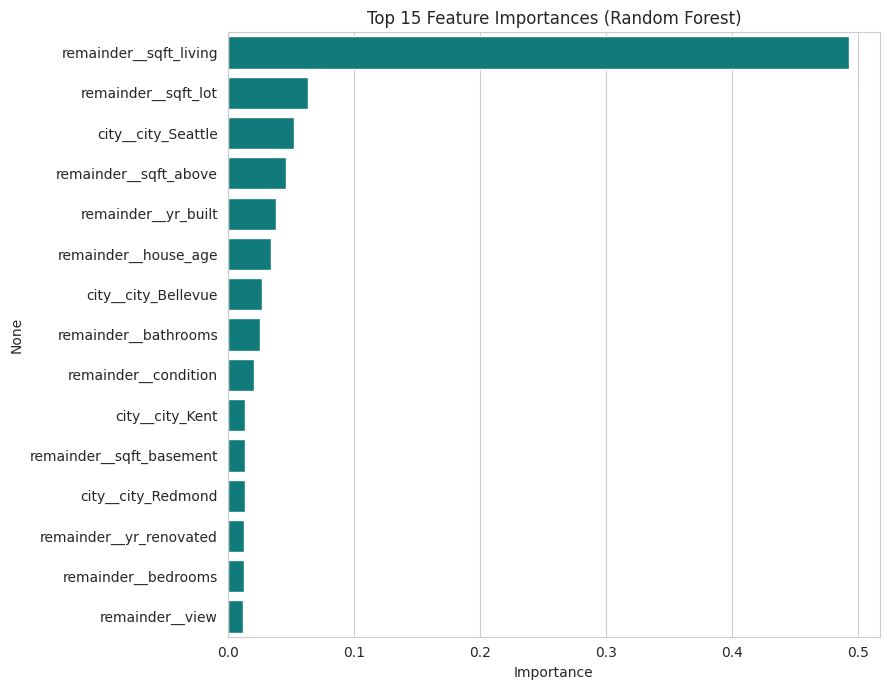

In [19]:
rf_pipe = models["Random Forest (log price)"]
rf_model = rf_pipe.named_steps["model"].regressor_
feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()

importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_importances.values, y=top_importances.index, color="darkcyan")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Conclusion

- **Data leakage matters:** including `price_per_sqft` inflates R² to ~0.9+, but that score is meaningless since the feature is derived from the target. Removing it gives an honest result instead.
- **Random Forest trained on log(price)** outperformed both plain Random Forest and Linear Regression on R², MAE, and MAPE — the log transform helps the model handle the right-skewed price distribution and extreme-value houses better.
- **Location (`city`) and `sqft_living`** are consistently among the strongest predictors.
- **Next steps to improve further:** use `statezip` as a finer-grained location signal, try Gradient Boosting / XGBoost, and tune hyperparameters with `GridSearchCV`.
